#run_neural_atsp_experiments

In [ ]:
!pip install osmnx

In [ ]:
# run_neural_experiments.py
# Эксперименты с нейросетевыми моделями для ATSP на реальных матрицах.
# Включает автоматическую распаковку архивов, гибридизацию всех моделей с 2-OPT,
# валидацию маршрутов по графу, визуализацию и расширенные графики.

import os
import zipfile
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import time
import osmnx as ox

from preprocess import load_preprocessed_matrices, load_warehouse_info
from classical import greedy_tsp, tsp_2opt, tabu_search_tsp
from neural_models import (
    PointerNetworkATSP, AttentionModelATSP, TSPGNNATSP,
    MatNet, MatPOENet, TSPGNNLearner
)
from utils import (
    calculate_route_distance, zip_folder, unzip_all,
    validate_route_on_graph, plot_route_on_map
)

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {DEVICE}")

OUTPUT_DIR = "neural_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

Используется устройство: cpu


In [ ]:
# 0. Распаковка архивов
def ensure_data_available():
    """Распаковывает все необходимые zip-архивы, создавая папки при необходимости."""
    # Архивы, которые нужно распаковать в отдельные папки
    model_archives = [
        "models_MatNet_12.zip", "models_MatNet_29.zip",
        "models_MatPOENet_12.zip", "models_MatPOENet_29.zip",
        "models_PointerNetworkATSP_12.zip", "models_PointerNetworkATSP_29.zip",
        "models_AttentionModelATSP_12.zip", "models_AttentionModelATSP_29.zip",
        "models_TSPGNNLearner_12.zip", "models_TSPGNNLearner_29.zip"
    ]
    # Архивы, которые уже содержат папку внутри
    data_archives = ["raw_data.zip", "preprocessed_data.zip"]

    for archive in data_archives:
        if os.path.exists(archive):
            print(f"Распаковываем {archive} в текущую папку")
            unzip_all([archive], extract_to=".")
        else:
            print(f"Архив {archive} не найден, пропускаем.")

    for archive in model_archives:
        if os.path.exists(archive):
            folder_name = archive.replace('.zip', '')   # e.g., "models_MatNet_12"
            os.makedirs(folder_name, exist_ok=True)
            print(f"Распаковываем {archive} в {folder_name}/")
            unzip_all([archive], extract_to=folder_name)
        else:
            print(f"Архив {archive} не найден, пропускаем.")

ensure_data_available()

Распаковываем raw_data.zip в текущую папку
Распаковываем raw_data.zip в .
Распакован: raw_data.zip
Распаковываем preprocessed_data.zip в текущую папку
Распаковываем preprocessed_data.zip в .
Распакован: preprocessed_data.zip
Распаковываем models_MatNet_12.zip в models_MatNet_12/
Распаковываем models_MatNet_12.zip в models_MatNet_12
Распакован: models_MatNet_12.zip
Распаковываем models_MatNet_29.zip в models_MatNet_29/
Распаковываем models_MatNet_29.zip в models_MatNet_29
Распакован: models_MatNet_29.zip
Распаковываем models_MatPOENet_12.zip в models_MatPOENet_12/
Распаковываем models_MatPOENet_12.zip в models_MatPOENet_12
Распакован: models_MatPOENet_12.zip
Распаковываем models_MatPOENet_29.zip в models_MatPOENet_29/
Распаковываем models_MatPOENet_29.zip в models_MatPOENet_29
Распакован: models_MatPOENet_29.zip
Распаковываем models_PointerNetworkATSP_12.zip в models_PointerNetworkATSP_12/
Распаковываем models_PointerNetworkATSP_12.zip в models_PointerNetworkATSP_12
Распакован: models_P

In [ ]:
# оригинальный граф для валидации и визуализации
GRAPH_PATH_CANDIDATES = ["raw_data/moscow_region_drive_network.graphml",
                         "moscow_region_drive_network.graphml"]
original_graph = None
for path in GRAPH_PATH_CANDIDATES:
    if os.path.exists(path):
        try:
            original_graph = ox.load_graphml(path)
            print(f"Граф загружен из {path}")
            break
        except Exception as e:
            print(f"Не удалось загрузить граф {path}: {e}")

Граф загружен из raw_data/moscow_region_drive_network.graphml


In [ ]:
# 1. Вспомогательные функции
def find_checkpoint(base_name, n_nodes):
    """
    Ищет чекпоинт в папках models_<Model>_<n_nodes>.
    Возвращает полный путь или None.
    """
    possible_dirs = [
        f"models_MatNet_{n_nodes}",
        f"models_MatPOENet_{n_nodes}",
        f"models_PointerNetworkATSP_{n_nodes}",
        f"models_AttentionModelATSP_{n_nodes}",
        f"models_TSPGNNLearner_{n_nodes}",
        "models",
        "."
    ]
    for d in possible_dirs:
        path = os.path.join(d, base_name)
        if os.path.exists(path):
            return path
    return None

def load_model_for_nodes(model_class, n_nodes, checkpoint_name, **kwargs):
    """Создаёт модель и загружает веса, если чекпоинт найден."""
    if model_class in [MatNet, MatPOENet]:
        model = model_class(n_nodes=n_nodes, **kwargs).to(DEVICE)
    elif model_class == PointerNetworkATSP:
        model = model_class(n_cities=n_nodes, **kwargs).to(DEVICE)
    elif model_class == AttentionModelATSP:
        model = model_class(n_cities=n_nodes, **kwargs).to(DEVICE)
    elif model_class == TSPGNNATSP:
        model = model_class(n_cities=n_nodes, **kwargs).to(DEVICE)
    elif model_class == TSPGNNLearner:
        model = model_class(n_cities=n_nodes, **kwargs).to(DEVICE)
    else:
        raise ValueError(f"Unknown model class: {model_class}")

    checkpoint_path = find_checkpoint(checkpoint_name, n_nodes)
    if checkpoint_path and os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE, weights_only=True))
        print(f"  Загружены веса из {checkpoint_path}")
        return model, True   # True – означает, что веса загружены
    else:
        print(f"  Веса {checkpoint_name} не найдены, используется случайная инициализация")
        return model, False  # False – необученная модель

def run_classical_baseline(dist_matrix, start_idx=0):
    """Запускает классические алгоритмы и возвращает словарь результатов."""
    results = {}
    route_g, dist_g, _ = greedy_tsp(dist_matrix, start_idx)
    results['Greedy'] = dist_g / 1000.0
    route_2opt, dist_2opt, _ = tsp_2opt(route_g, dist_matrix)
    results['2-OPT'] = dist_2opt / 1000.0
    try:
        route_tabu, dist_tabu, _ = tabu_search_tsp(dist_matrix, start_idx, max_iter=200)
        results['Tabu Search'] = dist_tabu / 1000.0
    except Exception as e:
        print(f"    Tabu Search ошибка: {e}")
        results['Tabu Search'] = None
    return results

def run_neural_inference(model, dist_matrix, start_idx=0, model_type='MatNet'):
    """
    Выполняет инференс нейросети, возвращает незамкнутый маршрут (list).
    Типы моделей:
        'GNN'          – TSPGNNATSP (необуч.)
        'GNNLearner'   – TSPGNNLearner (обуч.)
        'MatNet', 'MatPOENet' – матричные модели (возвращают незамкнутый маршрут)
        'Other'        – PointerNet, AttentionModel (возвращают замкнутый маршрут)
    """
    model.eval()
    with torch.no_grad():
        dist_tensor = torch.tensor(dist_matrix, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        if model_type == 'GNN':
            # TSPGNNATSP – возвращает heatmap, строим маршрут отдельно
            heatmap = model(dist_tensor)
            route = model.build_route_from_heatmap(heatmap, dist_tensor, start_idx)[0]
        elif model_type == 'GNNLearner':
            # TSPGNNLearner – обученная GNN, возвращает замкнутый маршрут при инференсе
            actions = model(dist_tensor, start_idx)          # (1, n+1)
            route = actions.squeeze(0).cpu().numpy().tolist()
            route = route[:-1]                                # убираем повтор старта
        elif model_type in ['MatNet', 'MatPOENet']:
            # уже возвращают незамкнутый маршрут, берём actions
            actions, _ = model(dist_tensor, start_idx)
            route = actions.squeeze(0).cpu().numpy().tolist()
        else:  # PointerNet, AttentionModel – возвращают замкнутый маршрут
            actions = model(dist_tensor, start_idx)          # (1, n+1)
            route = actions.squeeze(0).cpu().numpy().tolist()
            route = route[:-1]
    return route

def evaluate_route(route, dist_matrix):
    """Замыкает маршрут и вычисляет длину в км."""
    closed_route = route + [route[0]]
    return calculate_route_distance(closed_route, dist_matrix) / 1000.0

def apply_2opt(route, dist_matrix):
    """Применяет 2-OPT к замкнутому маршруту и возвращает улучшенный замкнутый маршрут и длину в метрах."""
    closed_route = route + [route[0]]
    improved_route, improved_dist, _ = tsp_2opt(closed_route, dist_matrix)
    return improved_route, improved_dist

In [ ]:
# 2. Валидация и визуализация
def validate_and_visualize_route(route, dist_matrix, warehouses_df, warehouse_nodes,
                                 scenario, algo_name, dist_km, force=False):
    """Если граф загружен, проверяет маршрут и сохраняет карту."""
    if original_graph is None:
        return
    if not force and (scenario != 'Без_шума' or
                      algo_name not in ['Tabu Search', 'MatNet+2-OPT', 'MatPOENet+2-OPT',
                                        'AttentionModel+2-OPT', 'PointerNet+2-OPT']):
        return

    closed_route = route + [route[0]]
    coords, graph_length, consistent = validate_route_on_graph(
        original_graph, closed_route, warehouse_nodes, dist_matrix, tolerance=1.0
    )
    if coords:
        title = f"{algo_name} на {scenario} ({dist_km:.2f} км)"
        fname = os.path.join(OUTPUT_DIR, f"route_{scenario.replace(' ', '_')}_{algo_name.replace(' ', '_')}.png")
        plot_route_on_map(coords, warehouses_df, closed_route, title, fname)

In [ ]:
# 3. Основной эксперимент для одного набора складов
def run_experiments_for_set(use_all=False, scenarios=None, start_idx=0):
    if scenarios is None:
        scenarios = ['Без_шума', 'Пробки', 'Блокировки_Пробки', 'Умеренные_условия']

    matrices = load_preprocessed_matrices(use_all=use_all)
    if not matrices:
        print(f"Матрицы для {'29' if use_all else '12'} складов не найдены.")
        return None, None

    n_nodes = next(iter(matrices.values())).shape[0]
    print(f"\nНейросетевые эксперименты для {n_nodes} складов")

    # Загрузка информации о складах
    warehouses_df = None
    warehouse_nodes = None
    try:
        warehouses_df = load_warehouse_info(use_all=use_all, scenario_name='Без_шума')
        warehouse_nodes = warehouses_df['node_id'].tolist()
    except Exception as e:
        print(f"Не удалось загрузить информацию о складах: {e}")

    # Инициализация моделей (словарь: имя -> модель)
    neural_models = {}

    # MatNet
    matnet_ckpt = f"MatNet_{n_nodes}_epoch_20.pt"
    neural_models['MatNet (обуч.)'], _ = load_model_for_nodes(
        MatNet, n_nodes, matnet_ckpt, embedding_dim=128, n_heads=8, n_layers=3, ff_dim=512
    )
    neural_models['MatNet (необуч.)'] = MatNet(n_nodes=n_nodes, embedding_dim=128,
                                               n_heads=8, n_layers=3, ff_dim=512).to(DEVICE)
    neural_models['MatNet (необуч.)'].eval()

    # MatPOENet
    matpoenet_ckpt = f"MatPOENet_{n_nodes}_epoch_20.pt"
    neural_models['MatPOENet (обуч.)'], _ = load_model_for_nodes(
        MatPOENet, n_nodes, matpoenet_ckpt, embedding_dim=128, n_heads=8, n_layers=3, ff_dim=512
    )
    neural_models['MatPOENet (необуч.)'] = MatPOENet(n_nodes=n_nodes, embedding_dim=128,
                                                    n_heads=8, n_layers=3, ff_dim=512).to(DEVICE)
    neural_models['MatPOENet (необуч.)'].eval()

    # PointerNetwork
    pointer_ckpt = f"PointerNetworkATSP_{n_nodes}_epoch_20.pt"
    neural_models['PointerNet (обуч.)'], _ = load_model_for_nodes(
        PointerNetworkATSP, n_nodes, pointer_ckpt, hidden_dim=128
    )
    neural_models['PointerNet (необуч.)'] = PointerNetworkATSP(n_nodes, hidden_dim=128).to(DEVICE)
    neural_models['PointerNet (необуч.)'].eval()

    # AttentionModel
    attention_ckpt = f"AttentionModelATSP_{n_nodes}_epoch_20.pt"
    neural_models['AttentionModel (обуч.)'], _ = load_model_for_nodes(
        AttentionModelATSP, n_nodes, attention_ckpt, embed_dim=128, num_layers=3, ff_dim=512
    )
    neural_models['AttentionModel (необуч.)'] = AttentionModelATSP(
        n_nodes, embed_dim=128, num_layers=3, ff_dim=512
    ).to(DEVICE)
    neural_models['AttentionModel (необуч.)'].eval()

    # GNN (обученная)
    gnn_ckpt = f"TSPGNNLearner_{n_nodes}_epoch_20.pt"
    neural_models['GNN (обуч.)'], gnn_loaded = load_model_for_nodes(
        TSPGNNLearner, n_nodes, gnn_ckpt, hidden_dim=128, num_layers=3
    )
    if not gnn_loaded:
        print("  GNN обуч. чекпоинт не найден, будет использована случайная инициализация")

    # GNN (необученная)
    neural_models['GNN (необуч.)'] = TSPGNNATSP(n_nodes, hidden_dim=128, num_layers=3).to(DEVICE)
    neural_models['GNN (необуч.)'].eval()

    all_results = []

    for scenario_name in scenarios:
        if scenario_name not in matrices:
            continue
        dist_matrix = matrices[scenario_name]
        print(f"\n  Сценарий: {scenario_name}")

        # Классические бейзлайны
        classic = run_classical_baseline(dist_matrix, start_idx)
        for algo, val in classic.items():
            if val is not None:
                all_results.append({
                    'warehouse_set': n_nodes,
                    'scenario': scenario_name,
                    'algorithm': algo,
                    'distance_km': val,
                    'time_sec': 0.0
                })
                print(f"  {algo:25}: {val:.2f} км")

        # Нейросети и гибриды
        for name, model in neural_models.items():
            try:
                t0 = time.time()
                # Определяем тип модели
                if 'GNN (обуч.)' in name:
                    model_type = 'GNNLearner'
                elif 'GNN (необуч.)' in name:
                    model_type = 'GNN'
                elif 'MatNet' in name and 'MatPOENet' not in name:
                    model_type = 'MatNet'
                elif 'MatPOENet' in name:
                    model_type = 'MatPOENet'
                else:
                    model_type = 'Other'  # PointerNet, AttentionModel

                route = run_neural_inference(model, dist_matrix, start_idx, model_type=model_type)
                dist_km = evaluate_route(route, dist_matrix)
                elapsed = time.time() - t0

                all_results.append({
                    'warehouse_set': n_nodes,
                    'scenario': scenario_name,
                    'algorithm': name,
                    'distance_km': dist_km,
                    'time_sec': elapsed
                })
                print(f"  {name:25}: {dist_km:.2f} км ({elapsed:.2f} с)")

                # Гибрид с 2-OPT
                improved_route, improved_dist_m = apply_2opt(route, dist_matrix)
                hybrid_km = improved_dist_m / 1000.0
                all_results.append({
                    'warehouse_set': n_nodes,
                    'scenario': scenario_name,
                    'algorithm': f'{name}+2-OPT',
                    'distance_km': hybrid_km,
                    'time_sec': elapsed + 0.001
                })
                print(f"  {name+'+2-OPT':25}: {hybrid_km:.2f} км")

                # Визуализация (только для лучших и только на сценарии "Без шума")
                if warehouses_df is not None and scenario_name == 'Без_шума':
                    if any(x in name for x in ['MatNet', 'MatPOENet', 'AttentionModel', 'PointerNet', 'GNN']):
                        validate_and_visualize_route(route, dist_matrix, warehouses_df, warehouse_nodes,
                                                     scenario_name, f'{name}+2-OPT', hybrid_km, force=True)

            except Exception as e:
                print(f"  {name:25}: ошибка - {e}")

    df = pd.DataFrame(all_results)
    return df, warehouses_df

In [ ]:
# 4. Графики
def plot_neural_comparison(df, title_prefix, filename):
    if df.empty:
        return
    subset = df[df['scenario'] == 'Без_шума'].sort_values('distance_km')
    if subset.empty:
        return

    plt.figure(figsize=(16, 14))
    algorithms = subset['algorithm'].tolist()
    values = subset['distance_km'].tolist()
    colors = []
    for a in algorithms:
        if '+2-OPT' in a:
            colors.append('#2ca02c')
        elif a in ['Greedy', '2-OPT', 'Tabu Search']:
            colors.append('#1f77b4')
        else:
            colors.append('#ff7f0e')

    bars = plt.barh(algorithms, values, color=colors, alpha=0.8)
    plt.xlabel('Длина маршрута (км)')
    plt.title(f'{title_prefix} — Сценарий "Без шума"')
    plt.gca().invert_yaxis()
    for bar, v in zip(bars, values):
        plt.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, f'{v:.1f}', va='center')

    best_classic = subset[subset['algorithm'].isin(['Tabu Search','2-OPT','Greedy'])]['distance_km'].min()
    plt.axvline(x=best_classic, color='red', linestyle='--', label=f'Лучший классический ({best_classic:.1f} км)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()
    print(f"График сохранён: {filename}")


Нейросетевые эксперименты для 12 складов
  Загружены веса из models_MatNet_12/MatNet_12_epoch_20.pt
  Загружены веса из models_MatPOENet_12/MatPOENet_12_epoch_20.pt
  Загружены веса из models_PointerNetworkATSP_12/PointerNetworkATSP_12_epoch_20.pt
  Загружены веса из models_AttentionModelATSP_12/AttentionModelATSP_12_epoch_20.pt
  Загружены веса из models_TSPGNNLearner_12/TSPGNNLearner_12_epoch_20.pt

  Сценарий: Без_шума
  Greedy                   : 406.84 км
  2-OPT                    : 406.84 км
  Tabu Search              : 406.34 км
  MatNet (обуч.)           : 579.05 км (0.01 с)
  MatNet (обуч.)+2-OPT     : 483.97 км
Длины совпадают: 579.05 км (разница 0.00 м)
Карта сохранена: neural_results/route_Без_шума_MatNet_(обуч.)+2-OPT.png
  MatNet (необуч.)         : 571.86 км (0.01 с)
  MatNet (необуч.)+2-OPT   : 429.57 км
Длины совпадают: 571.86 км (разница 0.00 м)
Карта сохранена: neural_results/route_Без_шума_MatNet_(необуч.)+2-OPT.png
  MatPOENet (обуч.)        : 624.71 км (0.01 с)


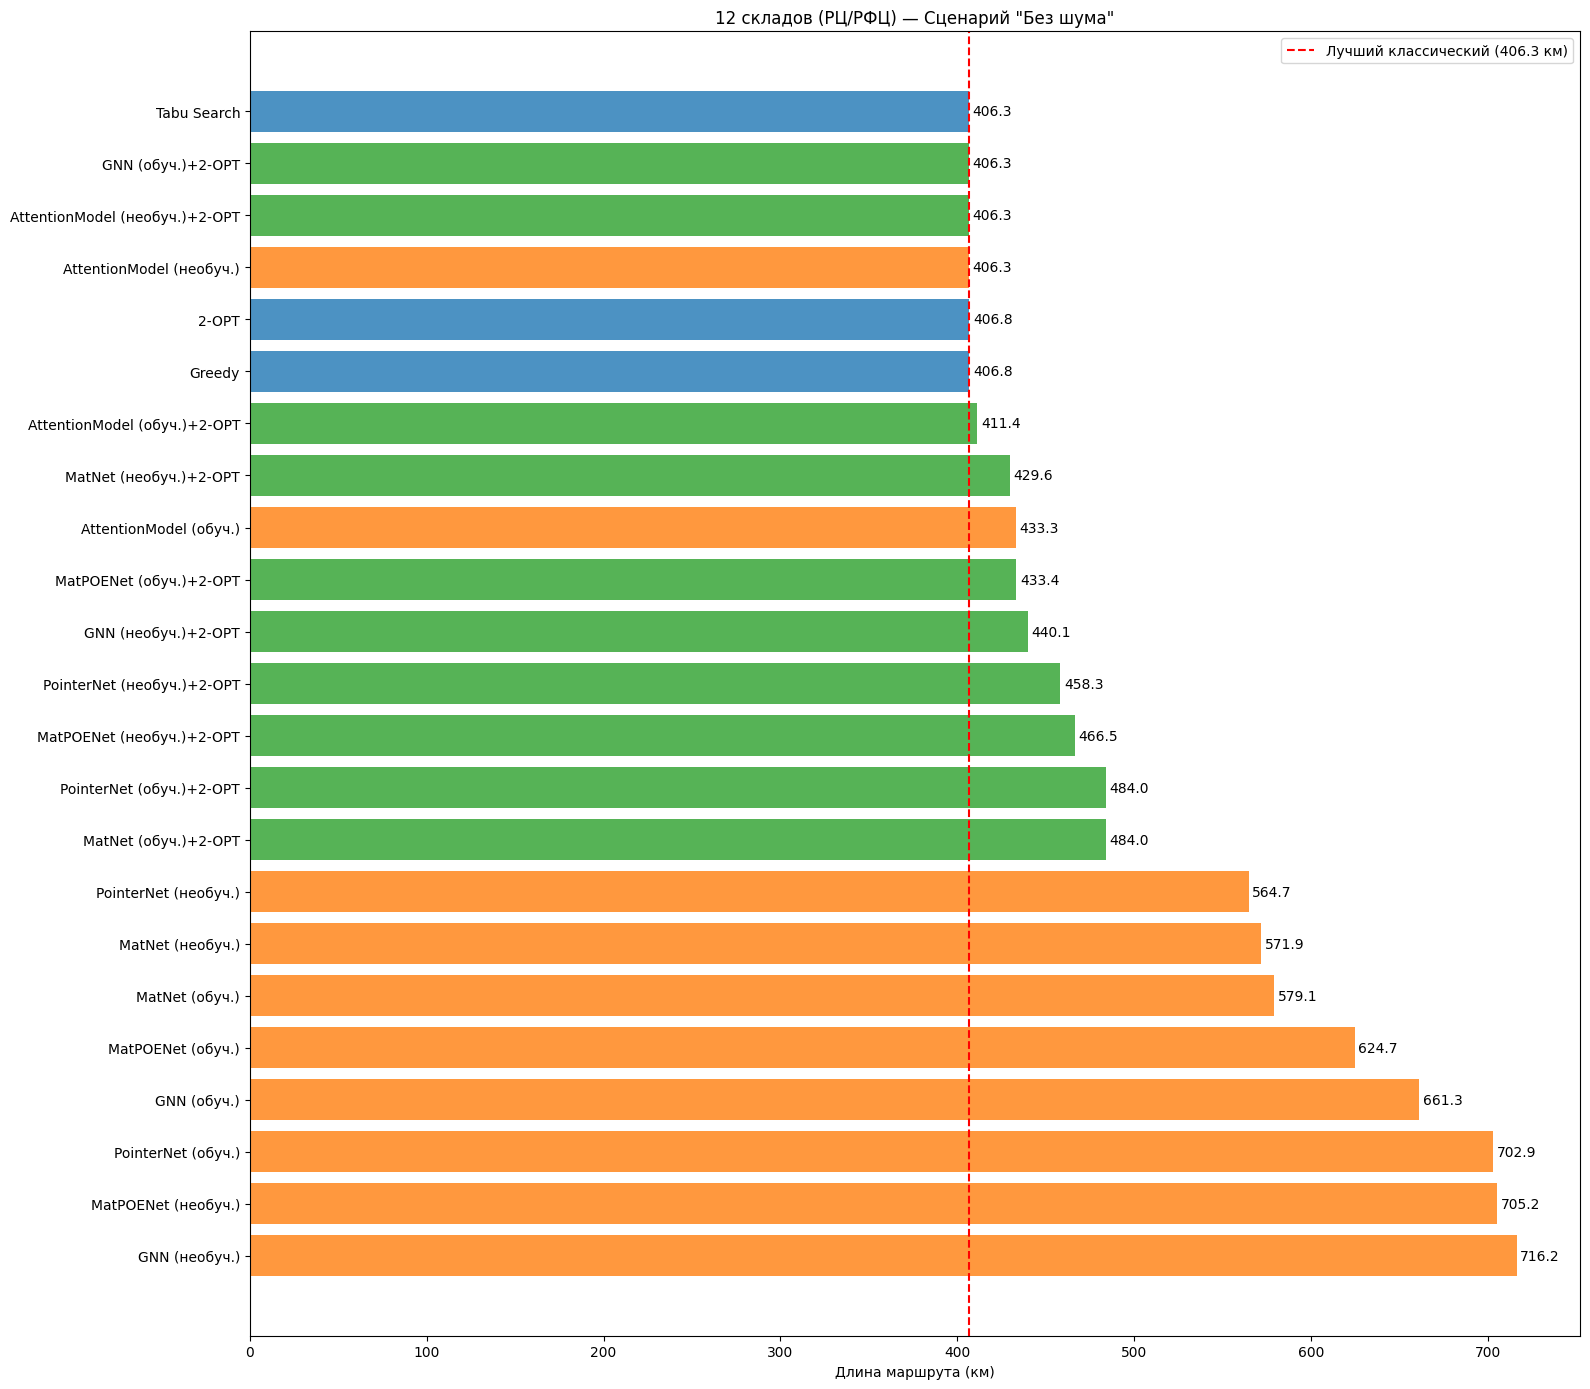

График сохранён: neural_results/comparison_12.png

Нейросетевые эксперименты для 29 складов
  Загружены веса из models_MatNet_29/MatNet_29_epoch_20.pt
  Загружены веса из models_MatPOENet_29/MatPOENet_29_epoch_20.pt
  Загружены веса из models_PointerNetworkATSP_29/PointerNetworkATSP_29_epoch_20.pt
  Загружены веса из models_AttentionModelATSP_29/AttentionModelATSP_29_epoch_20.pt
  Загружены веса из models_TSPGNNLearner_29/TSPGNNLearner_29_epoch_20.pt

  Сценарий: Без_шума
  Greedy                   : 712.65 км
  2-OPT                    : 635.97 км
  Tabu Search              : 637.75 км
  MatNet (обуч.)           : 1327.04 км (0.01 с)
  MatNet (обуч.)+2-OPT     : 700.70 км
Длины совпадают: 1327.04 км (разница 0.25 м)
Карта сохранена: neural_results/route_Без_шума_MatNet_(обуч.)+2-OPT.png
  MatNet (необуч.)         : 1313.80 км (0.01 с)
  MatNet (необуч.)+2-OPT   : 685.11 км
Длины совпадают: 1313.80 км (разница 0.12 м)
Карта сохранена: neural_results/route_Без_шума_MatNet_(необуч.)+2-OP

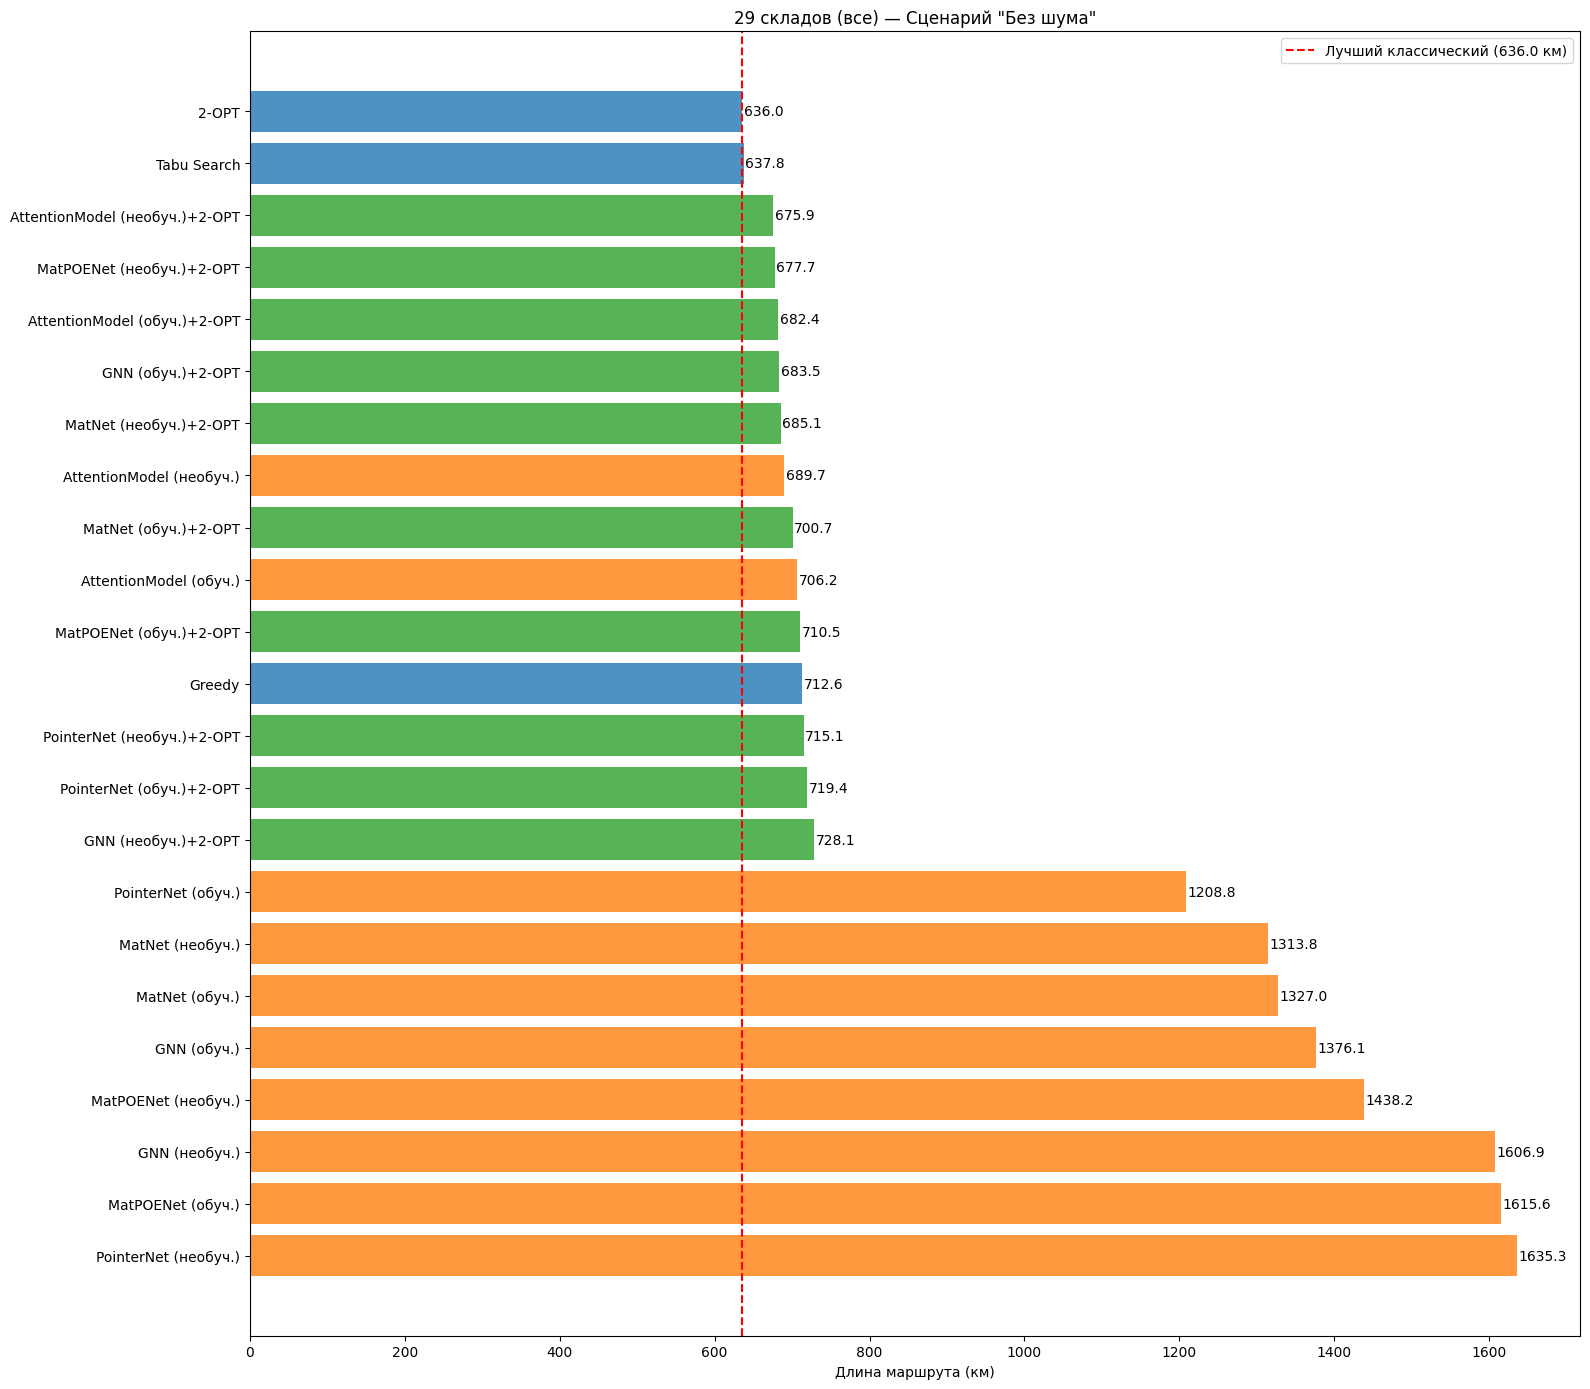

График сохранён: neural_results/comparison_29.png

Все результаты сохранены в папке 'neural_results'.
Папка neural_results заархивирована в neural_results.zip
Архив создан: neural_results.zip


In [ ]:
# 5. Точка входа
if __name__ == "__main__":
    # 12 складов
    df12, wh12 = run_experiments_for_set(use_all=False)
    if df12 is not None:
        df12.to_csv(os.path.join(OUTPUT_DIR, "results_12.csv"), index=False)
        plot_neural_comparison(df12, "12 складов (РЦ/РФЦ)",
                               os.path.join(OUTPUT_DIR, "comparison_12.png"))

    # 29 складов
    df29, wh29 = run_experiments_for_set(use_all=True)
    if df29 is not None:
        df29.to_csv(os.path.join(OUTPUT_DIR, "results_29.csv"), index=False)
        plot_neural_comparison(df29, "29 складов (все)",
                               os.path.join(OUTPUT_DIR, "comparison_29.png"))

    # Объединённый файл
    if df12 is not None and df29 is not None:
        combined = pd.concat([df12, df29], ignore_index=True)
        combined.to_csv(os.path.join(OUTPUT_DIR, "results_all.csv"), index=False)
        print("\nВсе результаты сохранены в папке 'neural_results'.")

    # Архивация
    if 'zip_folder' in globals():
        zip_path = zip_folder(OUTPUT_DIR)
        print(f"Архив создан: {zip_path}")
    else:
        print("Функция zip_folder не найдена.")

# старое


Нейросетевые эксперименты для 12 складов
  Загружены веса из models_MatNet_12/MatNet_12_epoch_20.pt
  Загружены веса из models_MatPOENet_12/MatPOENet_12_epoch_20.pt
  Загружены веса из models_PointerNetworkATSP_12/PointerNetworkATSP_12_epoch_20.pt
  Загружены веса из models_AttentionModelATSP_12/AttentionModelATSP_12_epoch_20.pt

  Сценарий: Без_шума
  Greedy                   : 406.84 км
  2-OPT                    : 406.84 км
  Tabu Search              : 406.34 км
  MatNet (обуч.)           : 579.05 км (0.38 с)
  MatNet (обуч.)+2-OPT     : 483.97 км
Длины совпадают: 579.05 км (разница 0.00 м)
Карта сохранена: neural_results/route_Без_шума_MatNet_(обуч.)+2-OPT.png
  MatPOENet (обуч.)        : 624.71 км (0.01 с)
  MatPOENet (обуч.)+2-OPT  : 433.37 км
Длины совпадают: 624.71 км (разница 0.00 м)
Карта сохранена: neural_results/route_Без_шума_MatPOENet_(обуч.)+2-OPT.png
  PointerNet (обуч.)       : 702.88 км (0.07 с)
  PointerNet (обуч.)+2-OPT : 483.97 км
Длины совпадают: 702.88 км (разни

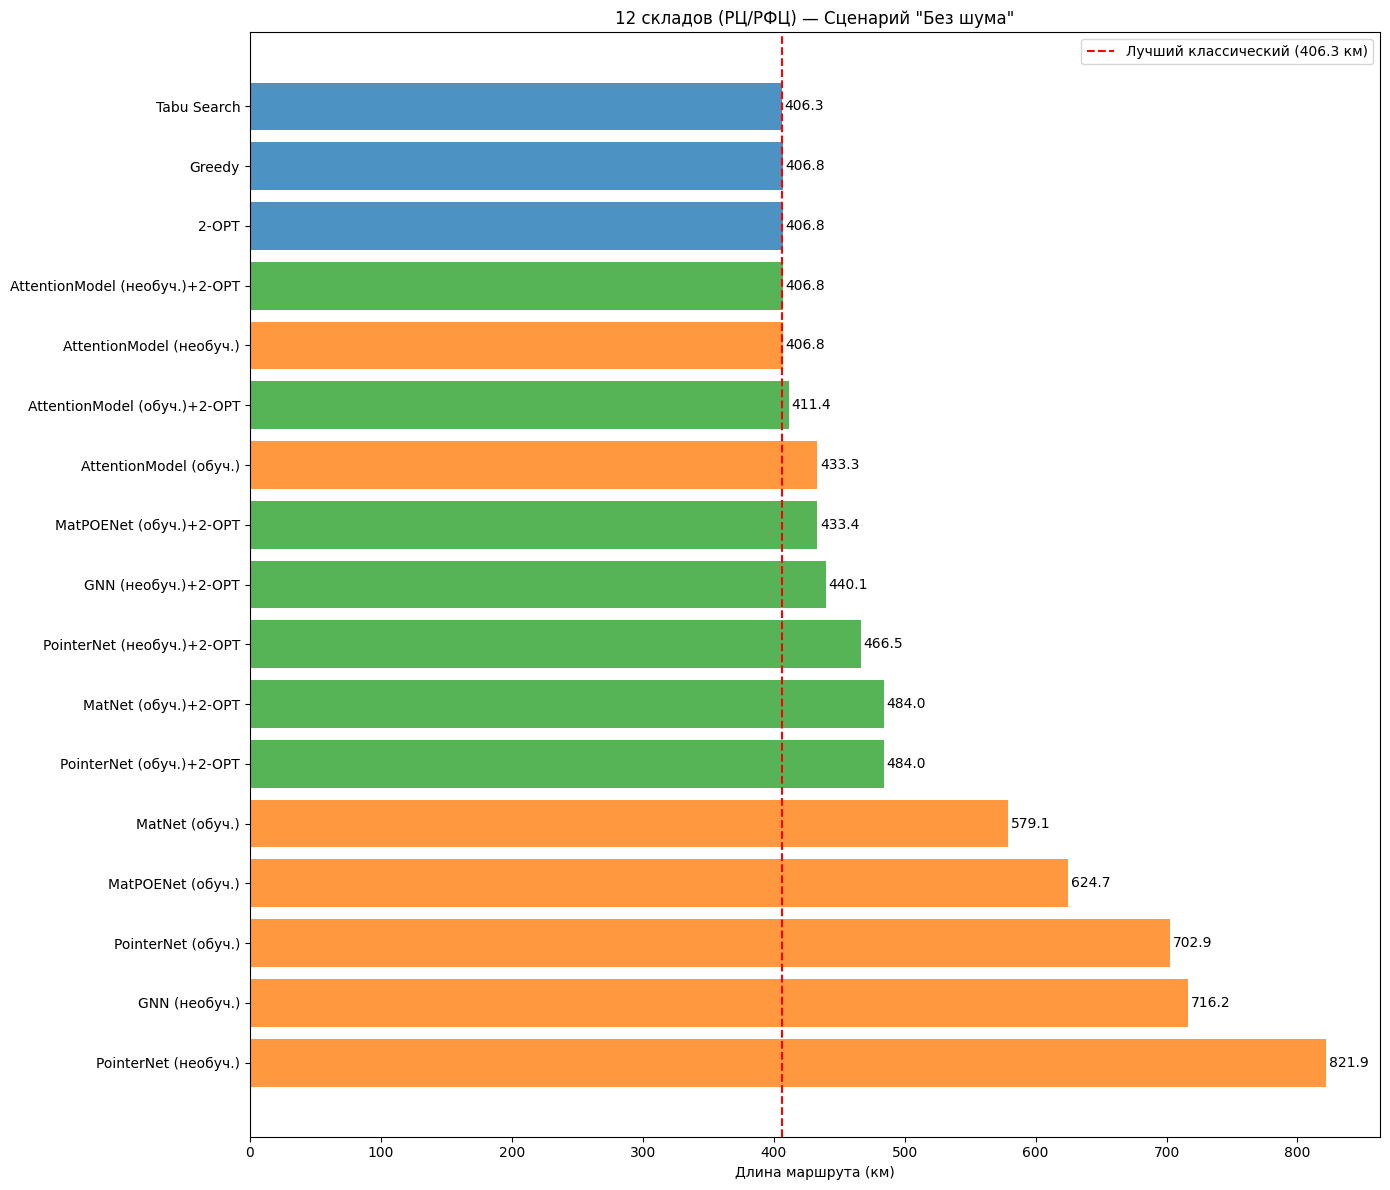

График сохранён: neural_results/comparison_12.png

Нейросетевые эксперименты для 29 складов
  Загружены веса из models_MatNet_29/MatNet_29_epoch_20.pt
  Загружены веса из models_MatPOENet_29/MatPOENet_29_epoch_20.pt
  Загружены веса из models_PointerNetworkATSP_29/PointerNetworkATSP_29_epoch_20.pt
  Загружены веса из models_AttentionModelATSP_29/AttentionModelATSP_29_epoch_20.pt

  Сценарий: Без_шума
  Greedy                   : 712.65 км
  2-OPT                    : 635.97 км
  Tabu Search              : 640.01 км
  MatNet (обуч.)           : 1327.04 км (0.01 с)
  MatNet (обуч.)+2-OPT     : 700.70 км
Длины совпадают: 1327.04 км (разница 0.25 м)
Карта сохранена: neural_results/route_Без_шума_MatNet_(обуч.)+2-OPT.png
  MatPOENet (обуч.)        : 1615.63 км (0.01 с)
  MatPOENet (обуч.)+2-OPT  : 710.46 км
Длины совпадают: 1615.63 км (разница 0.12 м)
Карта сохранена: neural_results/route_Без_шума_MatPOENet_(обуч.)+2-OPT.png
  PointerNet (обуч.)       : 1208.81 км (0.02 с)
  PointerNet (обу

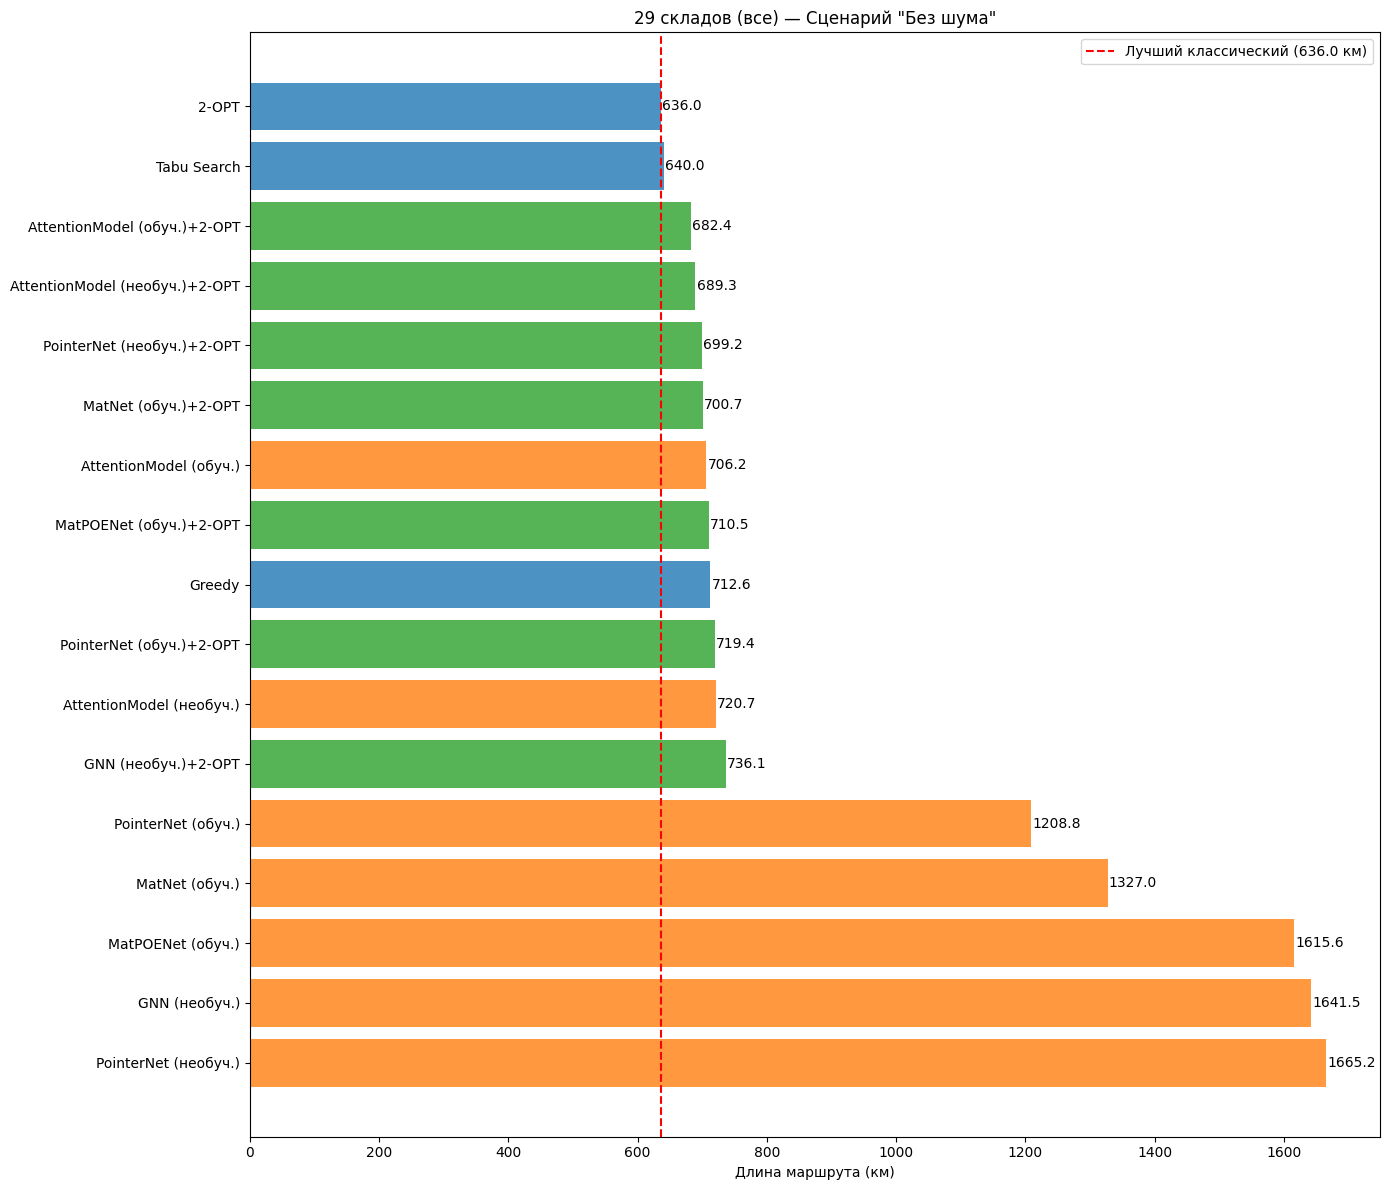

График сохранён: neural_results/comparison_29.png

Все результаты сохранены в папке 'neural_results'.
Папка neural_results заархивирована в neural_results.zip
Архив создан: neural_results.zip


In [ ]:
# 5. Точка входа
if __name__ == "__main__":
    # 12 складов
    df12, wh12 = run_experiments_for_set(use_all=False)
    if df12 is not None:
        df12.to_csv(os.path.join(OUTPUT_DIR, "results_12.csv"), index=False)
        plot_neural_comparison(df12, "12 складов (РЦ/РФЦ)",
                               os.path.join(OUTPUT_DIR, "comparison_12.png"))

    # 29 складов
    df29, wh29 = run_experiments_for_set(use_all=True)
    if df29 is not None:
        df29.to_csv(os.path.join(OUTPUT_DIR, "results_29.csv"), index=False)
        plot_neural_comparison(df29, "29 складов (все)",
                               os.path.join(OUTPUT_DIR, "comparison_29.png"))

    # Объединённый файл
    if df12 is not None and df29 is not None:
        combined = pd.concat([df12, df29], ignore_index=True)
        combined.to_csv(os.path.join(OUTPUT_DIR, "results_all.csv"), index=False)
        print("\nВсе результаты сохранены в папке 'neural_results'.")

    # Архивация
    if 'zip_folder' in globals():
        zip_path = zip_folder(OUTPUT_DIR)
        print(f"Архив создан: {zip_path}")
    else:
        print("Функция zip_folder не найдена.")